# Практическое задание
## Вариант 9
## Работу выполнила Ложникова Арина Сергеевна БИ-3-24-04

In [27]:
import numpy as np # работа с многомерными массивами
import pandas as pd # работа с DataFrame
import matplotlib.pyplot as plt # графики
import seaborn as sns # надстройка на matplotlib для красоты графиков
import math 
from scipy import stats # пакет стат. рас-ий
from scipy.stats import t
from scipy.stats import chi2, norm, uniform, expon
from scipy.stats import chi2
from scipy.stats import f
from scipy.interpolate import CubicSpline # Кубическая сплайн-интерполяция [для сглаживания кривых на графике эмипирческой]

## Задача 1
Для 100 элементов из заданной статистической совокупности:
  1. составить интервальный вариационный ряд (предварительно сделать очистку данных с помощью построения графика BoxPlot). Аргументировать выбранное число интервалов при построении интервального вариационного ряда;
  2. вычислить относительные частоты; вычислить значения эмпирической функции распределения;
  3. построить графики (гистограммы) относительных частот и эмпирической функции распределения;
  4. вычислить выборочные: среднее значение, дисперсию, среднеквадратическое отклонение и определить выборочные моду и медиану, коэффициенты асимметрии, эксцесса, вариации, децильный и квартильный коэффициенты вариации; сделать вывод;
  5. вычислить точечные и интервальные оценки генеральной средней, генеральной дисперсии и среднеквадратического отклонения с доверительной вероятностью  0,95. Построить графики плотности с доверительными интервалами;
  6. найти необходимый объем выборки для определения генерального среднего с предельной ошибкой 0,8 с доверительной вероятностью 0,95;
  7. проверить гипотезу о том, что генеральная совокупность имеет нормальное распределение на уровне значимости 0,05;привести график критической области;
  8. проверить гипотезу о том, что генеральная совокупность имеет равномерное распределение на уровне значимости 0,03; привести график критической области;
  9. проверить гипотезу о том, что генеральная совокупность имеет показательное распределение на уровне значимости 0,02; привести график критической области.

### Загрузка данных

In [2]:
data = np.array([9.52, 11.64, 4.20, 2.20, 3.74, 3.35, 8.77, 6.50, 4.41, 2.87,
                 2.37, 10.92, 5.59, 8.90, 10.97, 3.09, 4.00, 2.44, 3.75, 6.13,
                 9.68, 2.55, 7.90, 4.72, 2.58, 4.96, 10.30, 5.59, 5.48, 12.43,
                 8.82, 2.76, 4.41, 4.47, 10.90, 10.06, 9.00, 5.83, 6.30, 11.74,
                 5.25, 11.11, 7.90, 1.85, 6.79, 2.81, 0.24, 11.44, 2.24, -1.73,
                 7.34, 1.33, 10.03, 9.33, 8.97, 8.19, 10.99, 6.77, 2.49, 9.99,
                 4.79, 10.01, 6.24, 9.22, 9.21, 3.76, 5.71, 5.97, 8.06, 6.67,
                 23.35, 2.26, 8.23, 6.60, 4.58, 1.33, 12.17, 7.08, 10.75, 10.49,
                 8.43, 3.58, 8.66, 5.36, 3.48, 7.83, 12.25, 2.13, 8.28, 10.37,
                 2.15, 8.09, 8.51, 2.70, 10.87, 1.36, 6.04, 6.66, 4.00, 4.31])

print(f"Первоначальный размер выборки: {len(data)}")

Первоначальный размер выборки: 100


### Проверка наличия выбросов с помощью BoxPlot

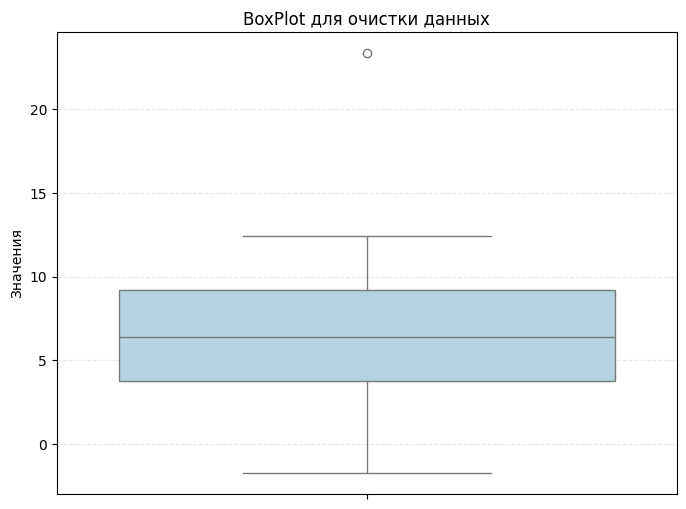

In [3]:
df = pd.DataFrame({'data': data})

plt.figure(figsize=(8, 6))
sns.boxplot(data=df, y='data', color='lightblue')
plt.title("BoxPlot для очистки данных")
plt.ylabel("Значения")
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

### Очистка данных через межквартальный размах
Данные содержат выброс, поэтому перед проведением статистического анализа необходимо очистить их. Избавить от выброса можно через вычисление межквартального размаха. 

In [4]:
# Есть выброс => делаем очистку с помощью межквартального размаха
Q1 = np.quantile(data, 0.25)
Q3 = np.quantile(data, 0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

delete = data[(data < lower) | (data > upper)]
print(f"Выбросы: {delete}")

data = data[(data >= lower) & (data <= upper)]
df = pd.DataFrame({'data': data})

print(f"Данные после очистки: {data}")
print(f"Размер выборки после очистки данных: {len(data)}")

Выбросы: [23.35]
Данные после очистки: [ 9.52 11.64  4.2   2.2   3.74  3.35  8.77  6.5   4.41  2.87  2.37 10.92
  5.59  8.9  10.97  3.09  4.    2.44  3.75  6.13  9.68  2.55  7.9   4.72
  2.58  4.96 10.3   5.59  5.48 12.43  8.82  2.76  4.41  4.47 10.9  10.06
  9.    5.83  6.3  11.74  5.25 11.11  7.9   1.85  6.79  2.81  0.24 11.44
  2.24 -1.73  7.34  1.33 10.03  9.33  8.97  8.19 10.99  6.77  2.49  9.99
  4.79 10.01  6.24  9.22  9.21  3.76  5.71  5.97  8.06  6.67  2.26  8.23
  6.6   4.58  1.33 12.17  7.08 10.75 10.49  8.43  3.58  8.66  5.36  3.48
  7.83 12.25  2.13  8.28 10.37  2.15  8.09  8.51  2.7  10.87  1.36  6.04
  6.66  4.    4.31]
Размер выборки после очистки данных: 99


### Построение интервального вариационного ряда

In [5]:
# Количество интервалов по формуле Стёрджесса
n = len(data)  # используем очищенные данные
k = math.floor(1 + math.log2(n))  # округление "до пола", т.е. берём только целую часть числа
print(f"Число интервалов по Стерджессу: k = {k}")

# Размах
R = np.max(data) - np.min(data)
# Ширина интервала
h = R / k
print(f"Ширина интервала (h): {round(h, 3)}")

# Границы интервалов
breaks = np.linspace(np.min(data), np.max(data), k + 1) # Используем linspace для создания равномерных границ

# Вариационный ряд
counts, bin_edges = np.histogram(data, bins=breaks)
intervals = pd.DataFrame({
    'Интервал': [f"[{round(bin_edges[i], 2)}; {round(bin_edges[i+1], 2)})" 
                 for i in range(len(bin_edges) - 1)],
    'Частота': counts
})
print(intervals.to_string())

Число интервалов по Стерджессу: k = 7
Ширина интервала (h): 2.023
         Интервал  Частота
0   [-1.73; 0.29)        2
1    [0.29; 2.32)        9
2    [2.32; 4.34)       20
3    [4.34; 6.36)       19
4    [6.36; 8.38)       16
5   [8.38; 10.41)       19
6  [10.41; 12.43)       14


### Нахождение относительных частот и значений эмпирической функции распределения

In [6]:
# Относительные частоты
CO = intervals['Частота'] / n

# Плотность относительной частоты
CO_h = CO / h

# Эмпирическая функция рас-ия
F_x = np.cumsum(CO)

intervals['Относительная_частота'] = np.round(CO, 4)
intervals['Плотность_относительной_частоты'] = np.round(CO_h, 4)
intervals['Накопленная_частота'] = np.round(F_x, 4)

print(intervals.to_string())

         Интервал  Частота  Относительная_частота  Плотность_относительной_частоты  Накопленная_частота
0   [-1.73; 0.29)        2                 0.0202                           0.0100               0.0202
1    [0.29; 2.32)        9                 0.0909                           0.0449               0.1111
2    [2.32; 4.34)       20                 0.2020                           0.0999               0.3131
3    [4.34; 6.36)       19                 0.1919                           0.0949               0.5051
4    [6.36; 8.38)       16                 0.1616                           0.0799               0.6667
5   [8.38; 10.41)       19                 0.1919                           0.0949               0.8586
6  [10.41; 12.43)       14                 0.1414                           0.0699               1.0000


### Гистограмма относительных частот

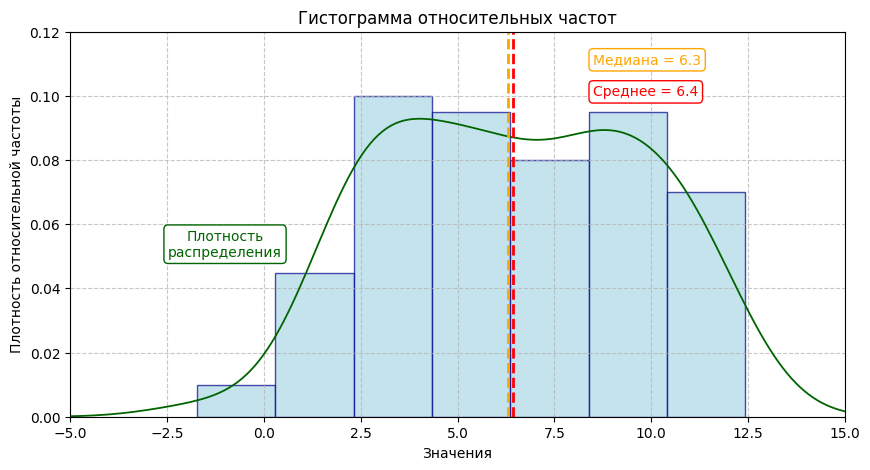

In [7]:
plt.figure(figsize=(10, 5))
plt.xlim(-5, 15) 
plt.ylim(0, 0.12) 
plt.hist(df['data'], bins=k, density=True, 
         color='lightblue', edgecolor='darkblue', alpha=0.7, linewidth=1)
sns.kdeplot(df['data'], color='darkgreen', linewidth=1.3)
plt.axvline(x=df['data'].mean(), color='red', linestyle='--', linewidth=2)
plt.axvline(x=df['data'].median(), color='orange', linestyle='--', linewidth=2)
plt.annotate(f'Среднее = {df['data'].mean():.1f}', xy=(8.5, 0.10), color='red', size=10,
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='red'))
plt.annotate(f'Медиана = {df['data'].median():.1f}', xy=(8.5, 0.11), color='orange', size=10,
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='orange'))
plt.annotate('Плотность\nраспределения', xy=(-1, 0.05), color='darkgreen', size=10, ha='center',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='darkgreen'))
plt.title('Гистограмма относительных частот')
plt.xlabel('Значения')
plt.ylabel('Плотность относительной частоты')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### График эмпирической функции распределения

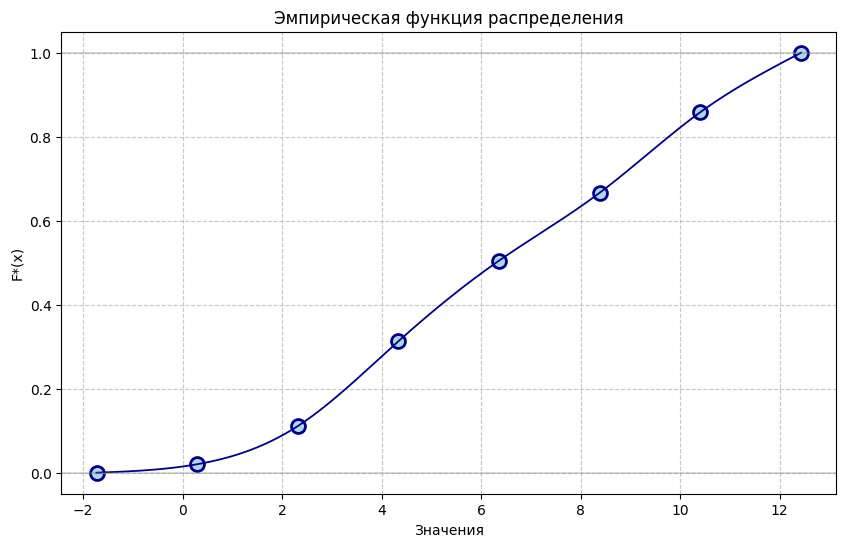

In [8]:
x_points = bin_edges
y_points = np.concatenate([[0], F_x])

df_points = pd.DataFrame({'x': x_points, 'y': y_points})

x_F = np.linspace(min(x_points), max(x_points), 500)
cs = CubicSpline(x_points, y_points, bc_type='natural')
y_F = cs(x_F)

df_F = pd.DataFrame({'x': x_F, 'y': y_F})

plt.figure(figsize=(10, 6))
plt.plot(df_F['x'], df_F['y'], color='darkblue', linewidth=1.3)
plt.scatter(df_points['x'], df_points['y'], s=100, facecolors='lightblue', edgecolors='darkblue', linewidth=2)
plt.title('Эмпирическая функция распределения')
plt.xlabel('Значения')
plt.ylabel('F*(x)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
plt.axhline(y=1, color='gray', linestyle='-', alpha=0.3)
plt.show()

### Вычисление выборочных характеристик

In [9]:
# Размер выборки
n = len(data)

# Среднее значение
mean = np.mean(data)
print(f"Среднее значение: {round(mean, 4)}")

# Несмещённая дисперсия (ddof=1 для несмещённой)
D = np.var(data, ddof=1)
# Смещённая дисперсия (ddof=0 для смещённой)
D_n = np.var(data, ddof=0)
print(f"Дисперсия (смещённая): {round(D_n, 4)}")
print(f"Дисперсия (несмещённая): {round(D, 4)}")

# Среднеквадратическое отклонение (несмещённое)
sd = np.std(data, ddof=1)
# Среднеквадратическое отклонение (смещённое)
sd_n = np.std(data, ddof=0)
print(f"Среднеквадратическое отклонение (смещённое): {round(sd_n, 4)}")
print(f"Среднеквадратическое отклонение (несмещённое): {round(sd, 4)}")

# Мода
Mo = df['data'].mode()[0]
print(f"Мода: {round(Mo, 4)}")

# Медиана
Me = np.median(data)
print(f"Медиана: {round(Me, 4)}")

# Коэффициент асимметрии
As = stats.skew(data)
print(f"Коэффициент асимметрии: {round(As, 4)}")

# Коэффициент эксцесса
Ex = stats.kurtosis(data, fisher=True)  # fisher=True даёт избыточный эксцесс
print(f"Коэффициент эксцесса: {round(Ex, 4)}")

# Коэффициент вариации
V = sd_n / mean
print(f"Коэффициент вариации: {round(V, 2)}")

# Квартили
Q1 = np.quantile(data, 0.25)
Q2 = np.quantile(data, 0.50)
Q3 = np.quantile(data, 0.75)

# Децили
D1 = np.quantile(data, 0.10)
D9 = np.quantile(data, 0.90)

# Квартильный коэффициент вариации
K_Q = (Q3 - Q1) / (2 * Me)
print(f"Квартильный коэффициент вариации: {round(K_Q, 4)}")

# Децильный коэффициент вариации
K_D = D9 / D1
print(f"Децильный коэффициент вариации: {round(K_D, 4)}")

Среднее значение: 6.438
Дисперсия (смещённая): 10.7919
Дисперсия (несмещённая): 10.9021
Среднеквадратическое отклонение (смещённое): 3.2851
Среднеквадратическое отклонение (несмещённое): 3.3018
Мода: 1.33
Медиана: 6.3
Коэффициент асимметрии: -0.0424
Коэффициент эксцесса: -0.9817
Коэффициент вариации: 0.51
Квартильный коэффициент вариации: 0.4254
Децильный коэффициент вариации: 4.8333


Выборка однородна по центру, так как среднее  и медиана практически равны, а асимметрия достаточно слабая. Однако присутствует сильный разброс: коэффициент вариации 51%, и распределение плосковершинное по эксцессу. При этом крайние значения сильно отличаются от центра (децильный коэффициент 4.83).

### Нахождение точечных и интервальных оценок

In [10]:
alpha = 1 - 0.95

# Точечные оценки
point_mean = mean
point_var = D
point_sd = sd

print(f"Точечная оценка генеральной средней: {round(point_mean, 4)}")
print(f"Точечная оценка генеральной дисперсии: {round(point_var, 4)}")
print(f"Точечная оценка СКО: {round(point_sd, 4)}")

# Интервальные оценки

# Среднее
t = stats.t.ppf(1 - alpha/2, n - 1)
delta = t * sd / np.sqrt(n)
mean_lower = mean - delta
mean_upper = mean + delta

print("\nДоверительный интервал для генеральной средней:")
print(f"[{round(mean_lower, 4)}; {round(mean_upper, 4)}]")

# Дисперсия
chi2_1 = stats.chi2.ppf(alpha/2, n - 1)
chi2_2 = stats.chi2.ppf(1 - alpha/2, n - 1)
D_lower = (n - 1) * D / chi2_2
D_upper = (n - 1) * D / chi2_1

print("Доверительный интервал для генеральной дисперсии:")
print(f"[{round(D_lower, 4)}; {round(D_upper, 4)}]")

# СКО
sd_lower = np.sqrt(D_lower)
sd_upper = np.sqrt(D_upper)

print("Доверительный интервал для генерального СКО:")
print(f"[{round(sd_lower, 4)}; {round(sd_upper, 4)}]")

Точечная оценка генеральной средней: 6.438
Точечная оценка генеральной дисперсии: 10.9021
Точечная оценка СКО: 3.3018

Доверительный интервал для генеральной средней:
[5.7794; 7.0965]
Доверительный интервал для генеральной дисперсии:
[8.394; 14.7364]
Доверительный интервал для генерального СКО:
[2.8972; 3.8388]


### График доверительного интервала для генеральной средней

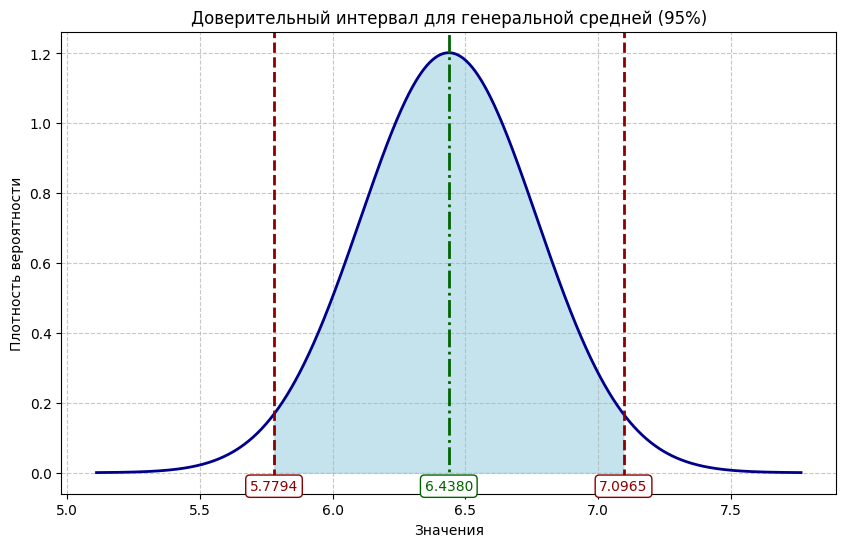

In [11]:
x_mean = np.linspace(mean - 4 * sd / np.sqrt(n), mean + 4 * sd / np.sqrt(n), 1000)
y_mean = norm.pdf(x_mean, loc=mean, scale=sd / np.sqrt(n))

df_mean = pd.DataFrame({'x': x_mean, 'y': y_mean})

df_mean_fill = df_mean[(df_mean['x'] >= mean_lower) & (df_mean['x'] <= mean_upper)]

plt.figure(figsize=(10, 6))
plt.plot(df_mean['x'], df_mean['y'], color='darkblue', linewidth=2)
plt.fill_between(df_mean_fill['x'], df_mean_fill['y'], color='lightblue', alpha=0.7)
plt.axvline(x=mean, color='darkgreen', linewidth=2, linestyle='-.')
plt.axvline(x=mean_lower, color='darkred', linewidth=2, linestyle='--')
plt.axvline(x=mean_upper, color='darkred', linewidth=2, linestyle='--')
plt.annotate(f'{mean:.4f}', xy=(mean, -0.05), ha='center', color='darkgreen',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='darkgreen'))
plt.annotate(f'{mean_lower:.4f}', xy=(mean_lower, -0.05), ha='center', color='darkred',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='darkred'))
plt.annotate(f'{mean_upper:.4f}', xy=(mean_upper, -0.05), ha='center', color='darkred',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='darkred'))
plt.title('Доверительный интервал для генеральной средней (95%)')
plt.xlabel('Значения')
plt.ylabel('Плотность вероятности')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### График доверительного интервала для генеральной длисперсии

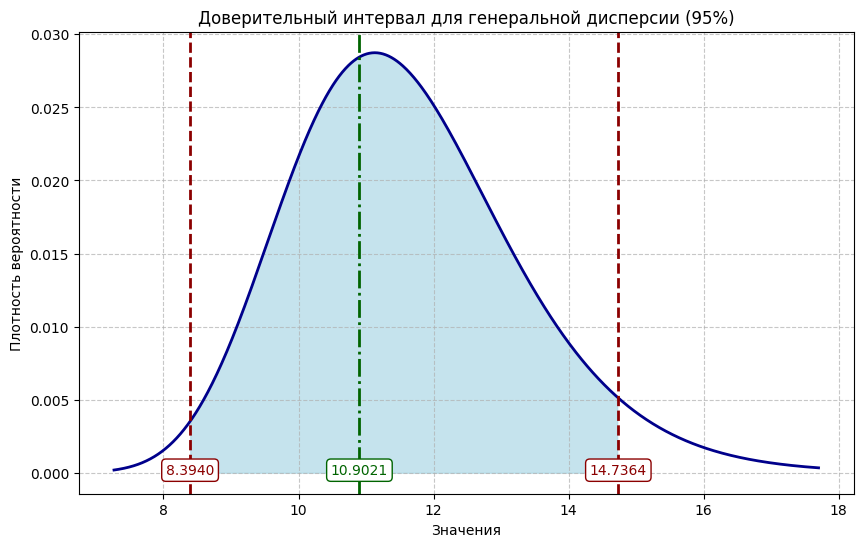

In [12]:
df_df = n - 1
help = np.linspace(chi2.ppf(0.001, df_df), chi2.ppf(0.999, df_df), 1000)
x_D = (df_df * D) / help
y_D = chi2.pdf(help, df_df)

df_D = pd.DataFrame({'x': x_D, 'y': y_D})

df_D_fill = df_D[(df_D['x'] >= D_lower) & (df_D['x'] <= D_upper)]

plt.figure(figsize=(10, 6))
plt.plot(df_D['x'], df_D['y'], color='darkblue', linewidth=2)
plt.fill_between(df_D_fill['x'], df_D_fill['y'], color='lightblue', alpha=0.7)
plt.axvline(x=D, color='darkgreen', linewidth=2, linestyle='-.')
plt.axvline(x=D_lower, color='darkred', linewidth=2, linestyle='--')
plt.axvline(x=D_upper, color='darkred', linewidth=2, linestyle='--')
plt.annotate(f'{D:.4f}', xy=(D, -0.0001), ha='center', color='darkgreen',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='darkgreen'))
plt.annotate(f'{D_lower:.4f}', xy=(D_lower, -0.0001), ha='center', color='darkred',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='darkred'))
plt.annotate(f'{D_upper:.4f}', xy=(D_upper, -0.0001), ha='center', color='darkred',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='darkred'))
plt.title('Доверительный интервал для генеральной дисперсии (95%)')
plt.xlabel('Значения')
plt.ylabel('Плотность вероятности')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### График доверительного интервала для генерального СКО

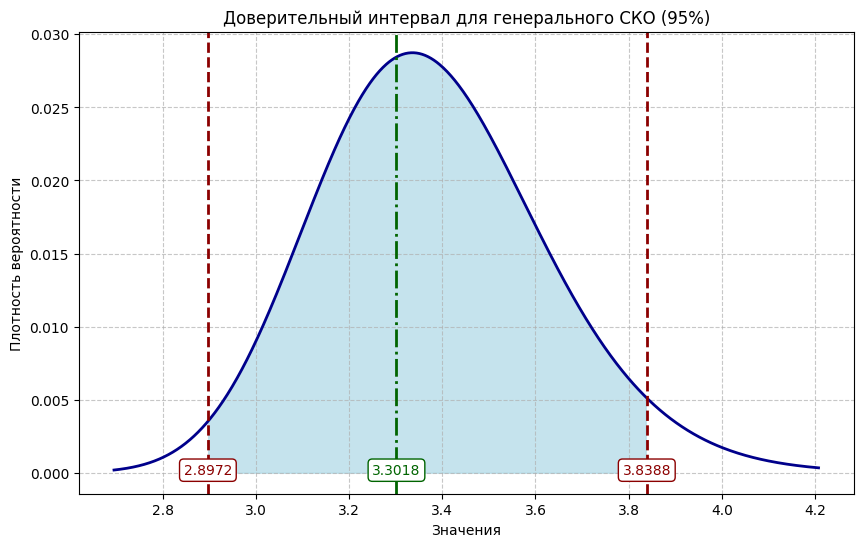

In [13]:
x_sd = np.sqrt(x_D)
y_sd = y_D

df_sd = pd.DataFrame({'x': x_sd, 'y': y_sd})
df_sd_fill = df_sd[(df_sd['x'] >= sd_lower) & (df_sd['x'] <= sd_upper)]

plt.figure(figsize=(10, 6))
plt.plot(df_sd['x'], df_sd['y'], color='darkblue', linewidth=2)
plt.fill_between(df_sd_fill['x'], df_sd_fill['y'], color='lightblue', alpha=0.7)
plt.axvline(x=sd, color='darkgreen', linewidth=2, linestyle='-.')
plt.axvline(x=sd_lower, color='darkred', linewidth=2, linestyle='--')
plt.axvline(x=sd_upper, color='darkred', linewidth=2, linestyle='--')
plt.annotate(f'{sd:.4f}', xy=(sd, -0.0001), ha='center', color='darkgreen',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='darkgreen'))
plt.annotate(f'{sd_lower:.4f}', xy=(sd_lower, -0.0001), ha='center', color='darkred',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='darkred'))
plt.annotate(f'{sd_upper:.4f}', xy=(sd_upper, -0.0001), ha='center', color='darkred',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='darkred'))
plt.title('Доверительный интервал для генерального СКО (95%)')
plt.xlabel('Значения')
plt.ylabel('Плотность вероятности')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Вычисление необходимого объёма выборки

In [14]:
delta = 0.8
alpha = 1 - 0.95

z = stats.norm.ppf(1 - alpha/2)

n_find = (z**2 * sd**2) / (delta**2)

print(f"Итог по формуле: {n_find}")

n_find = int(np.ceil(n_find))

print(f"Необходимый объем выборки: {n_find}")

Итог по формуле: 65.43721733779016
Необходимый объем выборки: 66


### Подготовка интервалов перед проверкой на вид распределения
Перед проверкой гипотез на вид рас-ия возможно необходимо объединить интервалы. В каждом интервале должно быть не мнее 5 значений => объединяем 1 и 2 интервалы

In [15]:
# Перед проверкой гипотез на вид рас-ия возможно необходимо объединить интервалы
# В каждом интервале должно быть не мнее 5 значений => объединяем 1 и 2 интервалы
breaks = np.concatenate([[bin_edges[0]], bin_edges[2:]])

n_i = np.concatenate([[np.sum(counts[:2])], counts[2:]])

print(f"Новое число интервалов k: {len(n_i)}")

Новое число интервалов k: 6


### Проверка гипотезы о том, про генеральная совокупность имеет нормальное распределение

H0: Генеральная совокупность имеет нормальное распределение
H1: Генеральная совокупность не имеет нормальное распределение
Уровень значимости: 0.05
Наблюдаемое значение X^2_набл: 5.1178
Критическое значение X^2_крит: 7.8147
X^2_набл < X^2_крит => H0 не отвергается


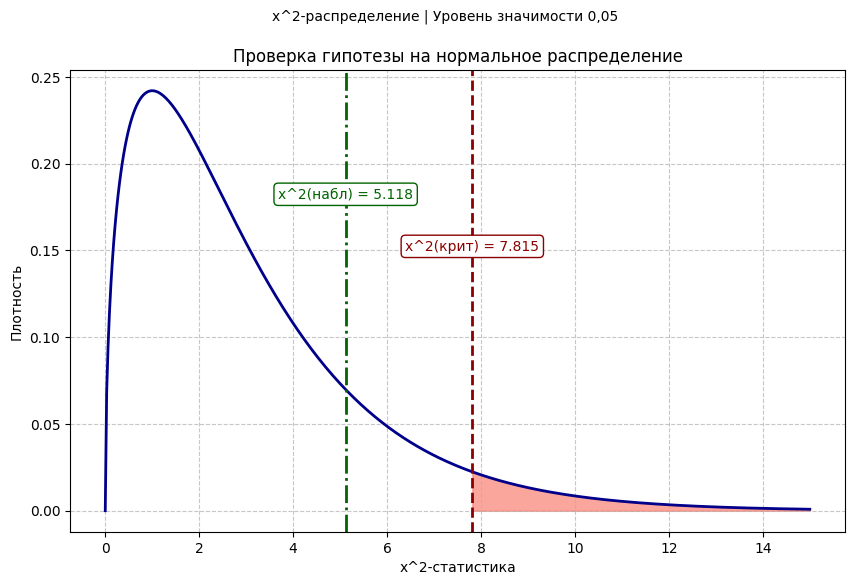

In [16]:
alpha = 0.05
df_n = len(n_i) - 2 - 1
breaks_norm = np.concatenate([[-np.inf], breaks[1:6], [np.inf]])

p_i = np.diff(norm.cdf(breaks_norm, mean, sd))
chi2_result = stats.chisquare(n_i, f_exp=np.sum(n_i) * p_i)
chi2_nabl = chi2_result.statistic

chi2_crit = chi2.ppf(1 - alpha, df_n)

print("H0: Генеральная совокупность имеет нормальное распределение")
print("H1: Генеральная совокупность не имеет нормальное распределение")
print(f"Уровень значимости: {alpha}")
print(f"Наблюдаемое значение X^2_набл: {round(chi2_nabl, 4)}")
print(f"Критическое значение X^2_крит: {round(chi2_crit, 4)}")

if chi2_nabl > chi2_crit:
    print("X^2_набл > X^2_крит => H0 отвергается")
else:
    print("X^2_набл < X^2_крит => H0 не отвергается")

x_chi = np.linspace(0, 15, 500)
y_chi = chi2.pdf(x_chi, df=df_n)
df_chi = pd.DataFrame({'x': x_chi, 'y': y_chi})

df_chi_fill = df_chi[df_chi['x'] >= chi2_crit]

plt.figure(figsize=(10, 6))
plt.fill_between(df_chi_fill['x'], df_chi_fill['y'], color='salmon', alpha=0.7)
plt.plot(df_chi['x'], df_chi['y'], color='darkblue', linewidth=2)
plt.axvline(x=chi2_crit, color='darkred', linestyle='--', linewidth=2)
plt.axvline(x=chi2_nabl, color='darkgreen', linestyle='-.', linewidth=2)
plt.annotate(f'x^2(крит) = {round(chi2_crit, 3)}', xy=(chi2_crit, 0.15), ha='center',
             color='darkred', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='darkred'))
plt.annotate(f'x^2(набл) = {round(chi2_nabl, 3)}', xy=(chi2_nabl, 0.18), ha='center',
             color='darkgreen', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='darkgreen'))
plt.title('Проверка гипотезы на нормальное распределение')
plt.suptitle('x^2-распределение | Уровень значимости 0,05', y=0.98, fontsize=10)
plt.xlabel('x^2-статистика')
plt.ylabel('Плотность')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Проверка гипотезы о том, про генеральная совокупность имеет равномерное распределение

H0: Генеральная совокупность имеет равномерное распределение
H1: Генеральная совокупность не имеет равномерное распределение
Уровень значимости: 0.03
Наблюдаемое значение X^2_набл: 1.4005
Критическое значение X^2_крит: 8.9473
X^2_набл < X^2_крит => H0 не отвергается


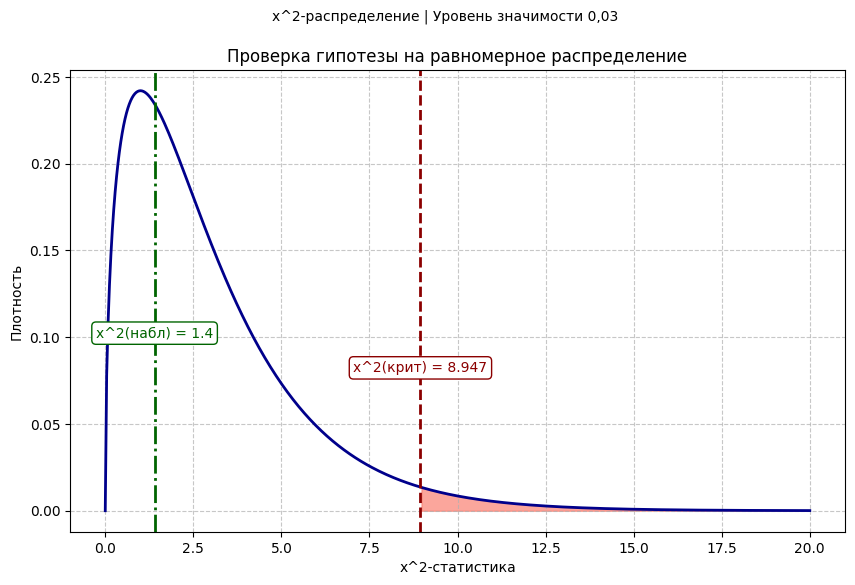

In [17]:
alpha = 0.03
df_n = len(n_i) - 2 - 1
a = mean - np.sqrt(3) * sd
b = mean + np.sqrt(3) * sd
breaks_ravn = np.concatenate([[a], breaks[1:6], [b]])

p_i = np.diff(uniform.cdf(breaks_ravn, a, b - a))
chi2_result = stats.chisquare(n_i, f_exp=np.sum(n_i) * p_i)
chi2_nabl = chi2_result.statistic

chi2_crit = chi2.ppf(1 - alpha, df_n)

print("H0: Генеральная совокупность имеет равномерное распределение")
print("H1: Генеральная совокупность не имеет равномерное распределение")
print(f"Уровень значимости: {alpha}")
print(f"Наблюдаемое значение X^2_набл: {round(chi2_nabl, 4)}")
print(f"Критическое значение X^2_крит: {round(chi2_crit, 4)}")

if chi2_nabl > chi2_crit:
    print("X^2_набл > X^2_крит => H0 отвергается")
else:
    print("X^2_набл < X^2_крит => H0 не отвергается")

x_chi = np.linspace(0, 20, 500)
y_chi = chi2.pdf(x_chi, df=df_n)
df_chi = pd.DataFrame({'x': x_chi, 'y': y_chi})

df_chi_fill = df_chi[df_chi['x'] >= chi2_crit]

plt.figure(figsize=(10, 6))
plt.fill_between(df_chi_fill['x'], df_chi_fill['y'], color='salmon', alpha=0.7)
plt.plot(df_chi['x'], df_chi['y'], color='darkblue', linewidth=2)
plt.axvline(x=chi2_crit, color='darkred', linestyle='--', linewidth=2)
plt.axvline(x=chi2_nabl, color='darkgreen', linestyle='-.', linewidth=2)
plt.annotate(f'x^2(крит) = {round(chi2_crit, 3)}', xy=(chi2_crit, 0.08), ha='center',
             color='darkred', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='darkred'))
plt.annotate(f'x^2(набл) = {round(chi2_nabl, 3)}', xy=(chi2_nabl, 0.10), ha='center',
             color='darkgreen', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='darkgreen'))
plt.title('Проверка гипотезы на равномерное распределение')
plt.suptitle('x^2-распределение | Уровень значимости 0,03', y=0.98, fontsize=10)
plt.xlabel('x^2-статистика')
plt.ylabel('Плотность')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Проверка гипотезы о том, про генеральная совокупность имеет показательное распределение

H0: Генеральная совокупность имеет показательное распределение
H1: Генеральная совокупность не имеет показательное распределение
Уровень значимости: 0.02
Наблюдаемое значение X^2_набл: 38.518
Критическое значение X^2_крит: 11.6678
X^2_набл > X^2_крит => H0 отвергается


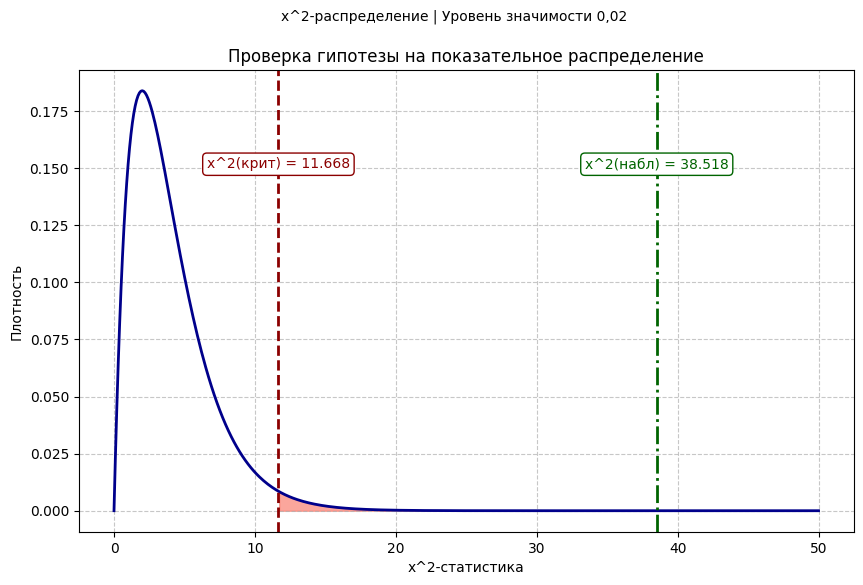

In [18]:
alpha = 0.02
df_n = len(n_i) - 1 - 1
breaks_exp = np.concatenate([[0], breaks[1:6], [np.inf]])

p_i = np.diff(expon.cdf(breaks_exp, scale=mean))
chi2_result = stats.chisquare(n_i, f_exp=np.sum(n_i) * p_i)
chi2_nabl = chi2_result.statistic

chi2_crit = chi2.ppf(1 - alpha, df_n)

print("H0: Генеральная совокупность имеет показательное распределение")
print("H1: Генеральная совокупность не имеет показательное распределение")
print(f"Уровень значимости: {alpha}")
print(f"Наблюдаемое значение X^2_набл: {round(chi2_nabl, 4)}")
print(f"Критическое значение X^2_крит: {round(chi2_crit, 4)}")

if chi2_nabl > chi2_crit:
    print("X^2_набл > X^2_крит => H0 отвергается")
else:
    print("X^2_набл < X^2_крит => H0 не отвергается")

x_chi = np.linspace(0, 50, 500)
y_chi = chi2.pdf(x_chi, df=df_n)
df_chi = pd.DataFrame({'x': x_chi, 'y': y_chi})

df_chi_fill = df_chi[df_chi['x'] >= chi2_crit]

plt.figure(figsize=(10, 6))
plt.fill_between(df_chi_fill['x'], df_chi_fill['y'], color='salmon', alpha=0.7)
plt.plot(df_chi['x'], df_chi['y'], color='darkblue', linewidth=2)
plt.axvline(x=chi2_crit, color='darkred', linestyle='--', linewidth=2)
plt.axvline(x=chi2_nabl, color='darkgreen', linestyle='-.', linewidth=2)
plt.annotate(f'x^2(крит) = {round(chi2_crit, 3)}', xy=(chi2_crit, 0.15), ha='center',
             color='darkred', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='darkred'))
plt.annotate(f'x^2(набл) = {round(chi2_nabl, 3)}', xy=(chi2_nabl, 0.15), ha='center',
             color='darkgreen', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='darkgreen'))
plt.title('Проверка гипотезы на показательное распределение')
plt.suptitle('x^2-распределение | Уровень значимости 0,02', y=0.98, fontsize=10)
plt.xlabel('x^2-статистика')
plt.ylabel('Плотность')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Задача 2
Считая, что первые 25 элементов из статистической совокупности образуют выборку А из генеральной совокупности X, а последние 20 элементов образуют выборку Б из генеральной совокупности Y проверить гипотезы о том, что
 1. генеральное среднее X равно m на уровне значимости 0,02, считая, что генеральная дисперсия известна и равна d;
 2. генеральное среднее Y равно m на уровне значимости 0,05, считая, что генеральная дисперсия неизвестна;
 3. генеральное среднее X равно генеральной средней Y на уровне значимости 0,05;
 4. генеральная дисперсия X равна d на уровне значимости 0,05;
 5. генеральная дисперсия X равна генеральной дисперсии выборки Б на уровне значимости 0,01. Во всех пунктах привести график критической области.

### Загрузка данных

In [56]:
# Выборка А
A = np.array([9.52, 11.64, 4.20, 2.20, 3.74, 3.35, 8.77, 6.50, 4.41, 2.87,
              2.37, 10.92, 5.59, 8.90, 10.97, 3.09, 4.00, 2.44, 3.75, 6.13,
              9.68, 2.55, 7.90, 4.72, 2.58])

# Выборка Б
B = np.array([8.43, 3.58, 8.66, 5.36, 3.48, 7.83, 12.25, 2.13, 8.28, 10.37,
              2.15, 8.09, 8.51, 2.70, 10.87, 1.36, 6.04, 6.66, 4.00, 4.31])

m = 6
d = 11

### Вычисление всех необходимых статистик

In [57]:
# Объёмы выборок
n_A = len(A)
n_B = len(B)

# Средние значения
mean_A = np.mean(A)
mean_B = np.mean(B)

# Дисперсии
D_A = np.var(A, ddof=1)
D_B = np.var(B, ddof=1)

# СКО
sd_A = np.std(A, ddof=1)
sd_B = np.std(B, ddof=1)

print(f"ВЫБОРКА А")
print(f"Объём выборки: {n_A}")
print(f"Среднее значение: {round(mean_A, 4)}")
print(f"Дисперсия: {round(D_A, 4)}")
print(f"СКО: {round(sd_A, 4)}")

print(f"\nВЫБОРКА Б")
print(f"Объём выборки: {n_B}")
print(f"Среднее значение: {round(mean_B, 4)}")
print(f"Дисперсия: {round(D_B, 4)}")
print(f"СКО: {round(sd_B, 4)}")

ВЫБОРКА А
Объём выборки: 25
Среднее значение: 5.7116
Дисперсия: 9.8105
СКО: 3.1322

ВЫБОРКА Б
Объём выборки: 20
Среднее значение: 6.253
Дисперсия: 10.259
СКО: 3.203


### Проверка гипотезы о равенстве среднего нормативу при известной генеральной дисперсии

H0: Среднее выборки A равно 6
H1: Среднее выборки A не равно 6
Уровень значимости: 0.02
Наблюдаемое значение Z_набл: -0.4348
Критическое значение Z_крит: +/- 2.3263
|Z_набл| < Z_крит => H0 не отвергается


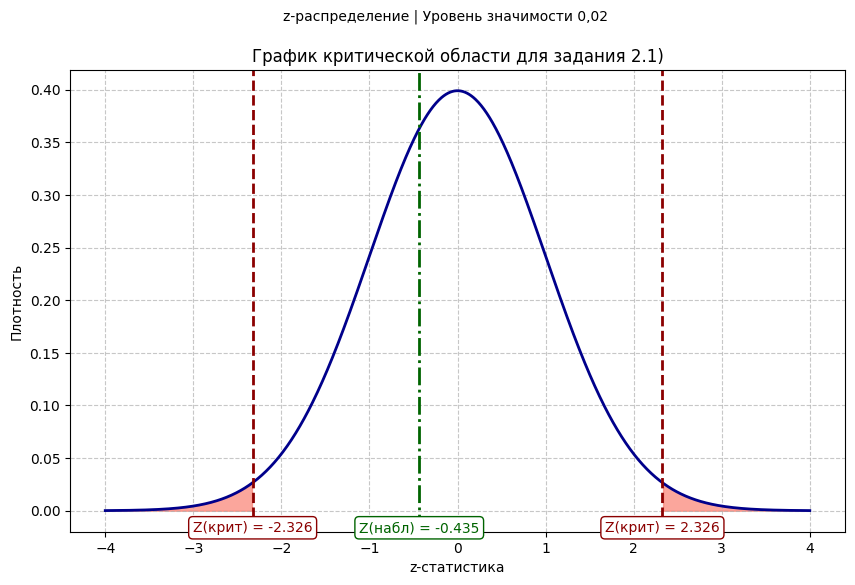

In [29]:
alpha = 0.02

z_nabl = (mean_A - m) / np.sqrt(d) * np.sqrt(n_A)

z_crit = stats.norm.ppf(1 - alpha/2)

print(f"H0: Среднее выборки A равно {m}")
print(f"H1: Среднее выборки A не равно {m}")

print(f"Уровень значимости: {alpha}")

print(f"Наблюдаемое значение Z_набл: {round(z_nabl, 4)}")
print(f"Критическое значение Z_крит: +/- {round(z_crit, 4)}")

if abs(z_nabl) > z_crit:
    print("|Z_набл| > Z_крит => H0 отвергается")
else:
    print("|Z_набл| < Z_крит => H0 не отвергается")

x_z = np.linspace(-4, 4, 1000)
y_z = norm.pdf(x_z, loc=0, scale=1)
df_z = pd.DataFrame({'x': x_z, 'y': y_z})

df_z_fill_1 = df_z[df_z['x'] <= -z_crit]
df_z_fill_2 = df_z[df_z['x'] >= z_crit]

plt.figure(figsize=(10, 6))
plt.fill_between(df_z_fill_1['x'], df_z_fill_1['y'], color='salmon', alpha=0.7)
plt.fill_between(df_z_fill_2['x'], df_z_fill_2['y'], color='salmon', alpha=0.7)
plt.plot(df_z['x'], df_z['y'], color='darkblue', linewidth=2)
plt.axvline(x=-z_crit, color='darkred', linestyle='--', linewidth=2)
plt.axvline(x=z_crit, color='darkred', linestyle='--', linewidth=2)
plt.axvline(x=z_nabl, color='darkgreen', linestyle='-.', linewidth=2)
plt.annotate(f'Z(крит) = {round(-z_crit, 3)}', xy=(-z_crit, -0.02), ha='center',
             color='darkred', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='darkred'))
plt.annotate(f'Z(крит) = {round(z_crit, 3)}', xy=(z_crit, -0.02), ha='center',
             color='darkred', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='darkred'))
plt.annotate(f'Z(набл) = {round(z_nabl, 3)}', xy=(z_nabl, -0.02), ha='center',
             color='darkgreen', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='darkgreen'))
plt.title('График критической области для задания 2.1)')
plt.suptitle('z-распределение | Уровень значимости 0,02', y=0.98, fontsize=10)
plt.xlabel('z-статистика')
plt.ylabel('Плотность')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Проверка гипотезы о равенстве среднего нормативу при неизвестной генеральной дисперсии

H0: Среднее выборки Б равно 6
H1: Среднее выборки Б не равно 6
Уровень значимости: 0.05
Наблюдаемое значение T_набл: 0.3533
Критическое значение t_крит: +/- 2.093
|T_набл| < t_крит => H0 не отвергается


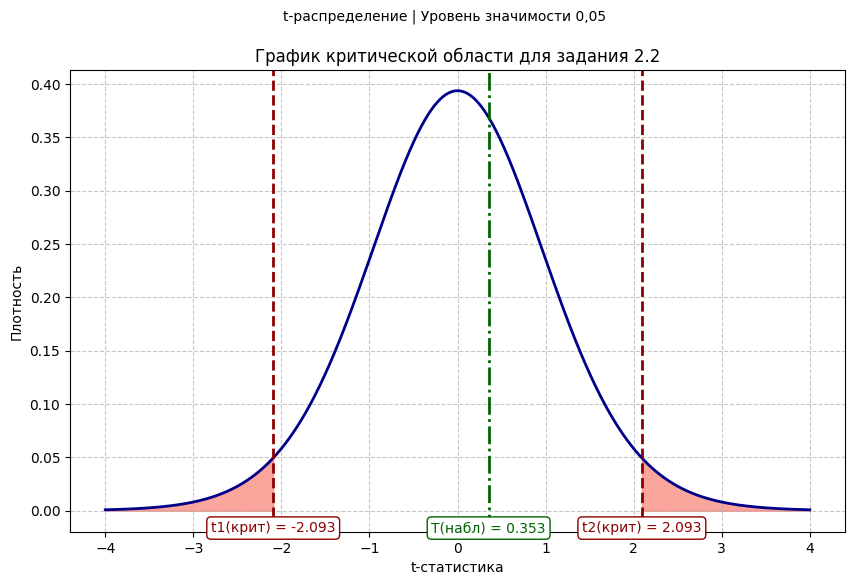

In [30]:
alpha = 0.05

t_nabl = (mean_B - m) / sd_B * np.sqrt(n_B)

t_crit = stats.t.ppf(1 - alpha/2, n_B - 1)

print(f"H0: Среднее выборки Б равно {m}")
print(f"H1: Среднее выборки Б не равно {m}")

print(f"Уровень значимости: {alpha}")

print(f"Наблюдаемое значение T_набл: {round(t_nabl, 4)}")
print(f"Критическое значение t_крит: +/- {round(t_crit, 4)}")

# Проверка гипотезы
if abs(t_nabl) > t_crit:
    print("|T_набл| > t_крит => H0 отвергается")
else:
    print("|T_набл| < t_крит => H0 не отвергается")

df_B = n_B - 1
x_t = np.linspace(-4, 4, 1000)
y_t = t.pdf(x_t, df=df_B)
df_t = pd.DataFrame({'x': x_t,'y': y_t})

df_t_fill_1 = df_t[df_t['x'] <= -t_crit]
df_t_fill_2 = df_t[df_t['x'] >= t_crit]

plt.figure(figsize=(10, 6))
plt.fill_between(df_t_fill_1['x'], df_t_fill_1['y'], color='salmon', alpha=0.7)
plt.fill_between(df_t_fill_2['x'], df_t_fill_2['y'], color='salmon', alpha=0.7)
plt.plot(df_t['x'], df_t['y'], color='darkblue', linewidth=2)
plt.axvline(x=-t_crit, color='darkred', linestyle='--', linewidth=2)
plt.axvline(x=t_crit, color='darkred', linestyle='--', linewidth=2)
plt.axvline(x=t_nabl, color='darkgreen', linestyle='-.', linewidth=2)
plt.annotate(f't1(крит) = {round(-t_crit, 3)}', xy=(-t_crit, -0.02), ha='center',
             color='darkred', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='darkred'))
plt.annotate(f't2(крит) = {round(t_crit, 3)}', xy=(t_crit, -0.02), ha='center',
             color='darkred', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='darkred'))
plt.annotate(f'T(набл) = {round(t_nabl, 3)}', xy=(t_nabl, -0.02), ha='center',
             color='darkgreen', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='darkgreen'))
plt.title('График критической области для задания 2.2')
plt.suptitle('t-распределение | Уровень значимости 0,05', y=0.98, fontsize=10)
plt.xlabel('t-статистика')
plt.ylabel('Плотность')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Проверка гипотезы о равенстве среднего значений двух выборок

H0: Среднее выборки А равно среднему выборки Б
H1: Среднее выборки А не равно среднему выборки Б
Уровень значимости: 0.05
Наблюдаемое значение T_набл: -0.0513
Критическое значение t_крит: +/- 2.0167
|T_набл| < t_крит => H0 не отвергается


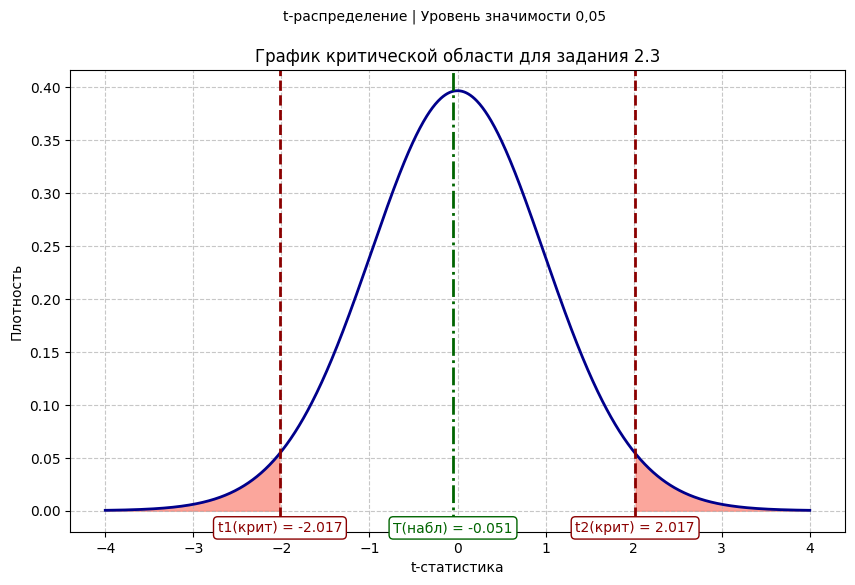

In [31]:
alpha = 0.05

t_nabl = (mean_A - mean_B) / np.sqrt(((n_A - 1) * D_A + (n_B - 1) * D_B) / (n_A + n_B - 2)) * np.sqrt(1/n_A + 1/n_B)

t_crit = stats.t.ppf(1 - alpha/2, n_A + n_B - 2)

print("H0: Среднее выборки А равно среднему выборки Б")
print("H1: Среднее выборки А не равно среднему выборки Б")

print(f"Уровень значимости: {alpha}")

print(f"Наблюдаемое значение T_набл: {round(t_nabl, 4)}")
print(f"Критическое значение t_крит: +/- {round(t_crit, 4)}")

if abs(t_nabl) > t_crit:
    print("|T_набл| > t_крит => H0 отвергается")
else:
    print("|T_набл| < t_крит => H0 не отвергается")

df_AB = n_A + n_B - 2
x_t = np.linspace(-4, 4, 1000)
y_t = t.pdf(x_t, df=df_AB)
df_t = pd.DataFrame({'x': x_t, 'y': y_t})

df_t_fill_1 = df_t[df_t['x'] <= -t_crit]
df_t_fill_2 = df_t[df_t['x'] >= t_crit]

plt.figure(figsize=(10, 6))
plt.fill_between(df_t_fill_1['x'], df_t_fill_1['y'], color='salmon', alpha=0.7)
plt.fill_between(df_t_fill_2['x'], df_t_fill_2['y'], color='salmon', alpha=0.7)
plt.plot(df_t['x'], df_t['y'], color='darkblue', linewidth=2)
plt.axvline(x=-t_crit, color='darkred', linestyle='--', linewidth=2)
plt.axvline(x=t_crit, color='darkred', linestyle='--', linewidth=2)
plt.axvline(x=t_nabl, color='darkgreen', linestyle='-.', linewidth=2)
plt.annotate(f't1(крит) = {round(-t_crit, 3)}', xy=(-t_crit, -0.02), ha='center',
             color='darkred', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='darkred'))
plt.annotate(f't2(крит) = {round(t_crit, 3)}', xy=(t_crit, -0.02), ha='center',
             color='darkred', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='darkred'))
plt.annotate(f'T(набл) = {round(t_nabl, 3)}', xy=(t_nabl, -0.02), ha='center',
             color='darkgreen',bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='darkgreen'))
plt.title('График критической области для задания 2.3')
plt.suptitle('t-распределение | Уровень значимости 0,05', y=0.98, fontsize=10)
plt.xlabel('t-статистика')
plt.ylabel('Плотность')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Проверка гипотезы о равенстве дисперсии нормативу

H0: Дисперсия выборки А равна 11
H1: Дисперсия выборки А не равна 11
Уровень значимости: 0.05
Наблюдаемое значение X^2_набл: 21.4047
Критическое значение X^2_крит_1: 12.4012
Критическое значение X^2_крит_2: 39.3641
X^2_крит_1 < X^2_набл < X^2_крит_2 => H0 не отвергается


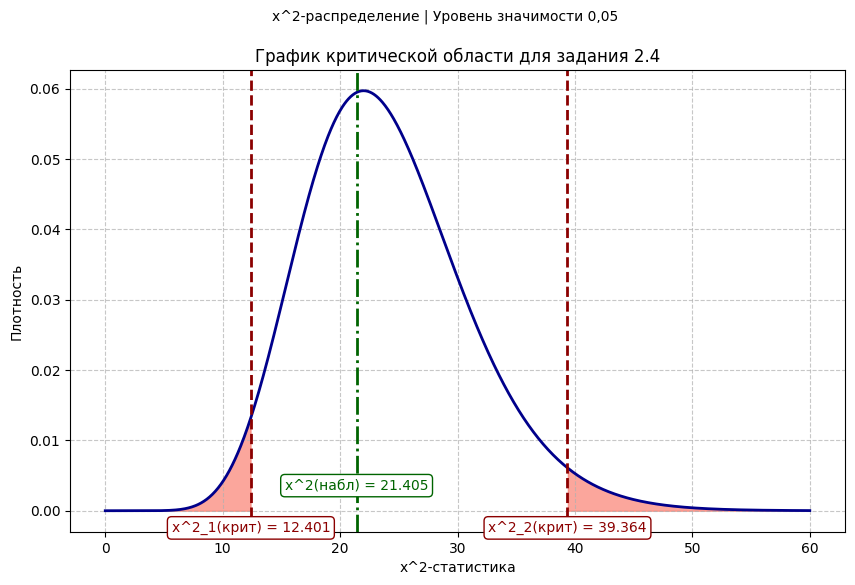

In [32]:
alpha = 0.05

chi2_nabl = D_A * (n_A - 1) / d

chi2_crit_1 = stats.chi2.ppf(alpha/2, n_A - 1)
chi2_crit_2 = stats.chi2.ppf(1 - alpha/2, n_A - 1)

print(f"H0: Дисперсия выборки А равна {d}")
print(f"H1: Дисперсия выборки А не равна {d}")

print(f"Уровень значимости: {alpha}")

print(f"Наблюдаемое значение X^2_набл: {round(chi2_nabl, 4)}")
print(f"Критическое значение X^2_крит_1: {round(chi2_crit_1, 4)}")
print(f"Критическое значение X^2_крит_2: {round(chi2_crit_2, 4)}")

if chi2_nabl < chi2_crit_1 or chi2_nabl > chi2_crit_2:
    print("X^2_набл < X^2_крит_1 или X^2_набл > X^2_крит_2 => H0 отвергается")
else:
    print("X^2_крит_1 < X^2_набл < X^2_крит_2 => H0 не отвергается")

df_df = n_A - 1
x_chi = np.linspace(0, 60, 1000)
y_chi = chi2.pdf(x_chi, df=df_df)
df_chi = pd.DataFrame({'x': x_chi, 'y': y_chi})

df_chi_fill_1 = df_chi[df_chi['x'] <= chi2_crit_1]
df_chi_fill_2 = df_chi[df_chi['x'] >= chi2_crit_2]

plt.figure(figsize=(10, 6))
plt.fill_between(df_chi_fill_1['x'], df_chi_fill_1['y'], color='salmon', alpha=0.7)
plt.fill_between(df_chi_fill_2['x'], df_chi_fill_2['y'], color='salmon', alpha=0.7)
plt.plot(df_chi['x'], df_chi['y'], color='darkblue', linewidth=2)
plt.axvline(x=chi2_crit_1, color='darkred', linestyle='--', linewidth=2)
plt.axvline(x=chi2_crit_2, color='darkred', linestyle='--', linewidth=2)
plt.axvline(x=chi2_nabl, color='darkgreen', linestyle='-.', linewidth=2)
plt.annotate(f'x^2_1(крит) = {round(chi2_crit_1, 3)}', xy=(chi2_crit_1, -0.003), ha='center',
             color='darkred', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='darkred'))
plt.annotate(f'x^2_2(крит) = {round(chi2_crit_2, 3)}', xy=(chi2_crit_2, -0.003), ha='center',
             color='darkred', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='darkred'))
plt.annotate(f'x^2(набл) = {round(chi2_nabl, 3)}', xy=(chi2_nabl, 0.003), ha='center',
             color='darkgreen', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='darkgreen'))
plt.title('График критической области для задания 2.4')
plt.suptitle('x^2-распределение | Уровень значимости 0,05', y=0.98, fontsize=10)
plt.xlabel('x^2-статистика')
plt.ylabel('Плотность')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Проверка гипотезы о равенстве дисперсий двух выборок

H0: Дисперсии выборок А и Б равны
H1: Дисперсии выборок А и Б не равны
Уровень значимости: 0.01
Наблюдаемое значение F_набл: 1.0457
Критическое значение F_крит_1: 0.3025
Критическое значение F_крит_2: 3.092
F_крит_1 < F_набл < F_крит_2 => H0 не отвергается


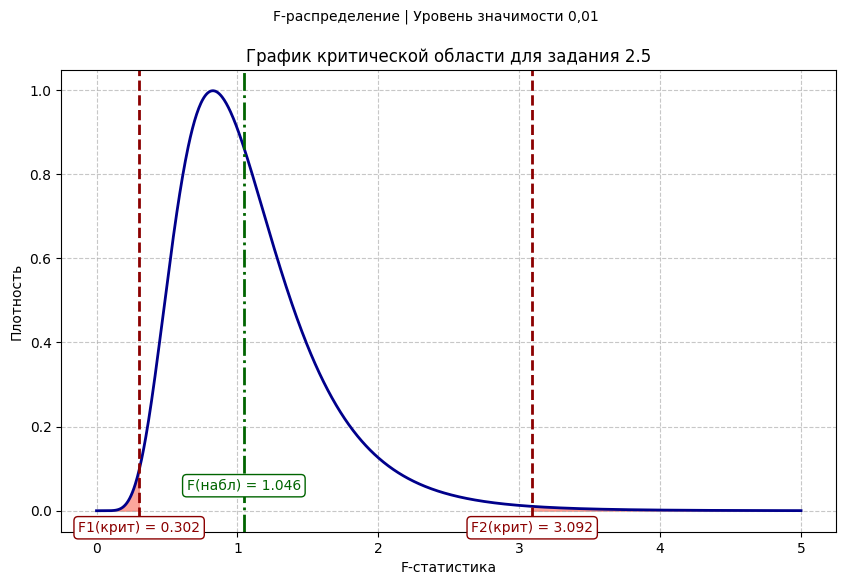

In [50]:
alpha = 0.01

F_nabl = D_B / D_A

F_crit_1 = stats.f.ppf(alpha/2, n_B-1, n_A-1)
F_crit_2 = stats.f.ppf(1 - alpha/2, n_B-1, n_A-1)

print(f"H0: Дисперсии выборок А и Б равны")
print(f"H1: Дисперсии выборок А и Б не равны")

print(f"Уровень значимости: {alpha}")

print(f"Наблюдаемое значение F_набл: {round(F_nabl, 4)}")
print(f"Критическое значение F_крит_1: {round(F_crit_1, 4)}")
print(f"Критическое значение F_крит_2: {round(F_crit_2, 4)}")

if F_nabl < F_crit_1 or F_nabl > F_crit_2:
    print("F_набл < F_крит_1 или F_набл > F_крит_2 => H0 отвергается")
else:
    print("F_крит_1 < F_набл < F_крит_2 => H0 не отвергается")

df1_F = n_B - 1
df2_F = n_A - 1

x_F = np.linspace(0, 5, 1000)
y_F = f.pdf(x_F, dfn=df1_F, dfd=df2_F)
df_F = pd.DataFrame({'x': x_F, 'y': y_F})

df_F_fill_1 = df_F[df_F['x'] <= F_crit_1]
df_F_fill_2 = df_F[df_F['x'] >= F_crit_2]

plt.figure(figsize=(10, 6))
plt.fill_between(df_F_fill_1['x'], df_F_fill_1['y'], color='salmon', alpha=0.7)
plt.fill_between(df_F_fill_2['x'], df_F_fill_2['y'], color='salmon', alpha=0.7)
plt.plot(df_F['x'], df_F['y'], color='darkblue', linewidth=2)
plt.axvline(x=F_crit_1, color='darkred', linestyle='--', linewidth=2)
plt.axvline(x=F_crit_2, color='darkred', linestyle='--', linewidth=2)
plt.axvline(x=F_nabl, color='darkgreen', linestyle='-.', linewidth=2)
plt.annotate(f'F1(крит) = {round(F_crit_1, 3)}', xy=(F_crit_1, -0.05), ha='center',
             color='darkred', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='darkred'))
plt.annotate(f'F2(крит) = {round(F_crit_2, 3)}', xy=(F_crit_2, -0.05), ha='center',
             color='darkred', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='darkred'))
plt.annotate(f'F(набл) = {round(F_nabl, 3)}', xy=(F_nabl, 0.05), ha='center',
             color='darkgreen', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='darkgreen'))
plt.title('График критической области для задания 2.5')
plt.suptitle('F-распределение | Уровень значимости 0,01', y=0.98, fontsize=10)
plt.xlabel('F-статистика')
plt.ylabel('Плотность')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Задача 3
Построить линии регрессии с помощью метода натянутой нити и метода наименьших квадратов для связанных выборок XY, XZ и YZ. Проверить гипотезу о значимости коэффициента корреляции. Сделать прогноз для значения x на 4 единицы больше максимального значения. Построить графики.

### Загрузка данных

In [58]:
x = np.array([3.67, 5.94, 3.80, 5.40, 1.45, 5.45, 2.13, 0.30, 4.29, 6.00,
              2.11, 2.96, 1.35, 2.63, 0.37, 2.90, 0.51, 1.83, 3.10, 5.58,
              4.73, 3.10, 3.79, 5.52, 3.21, 0.28, 1.18, 3.09])

y = np.array([1.77, 0.28, 1.78, 0.95, 0.46, 1.00, 1.89, 0.20, 0.63, 1.58,
              0.80, 1.98, 0.83, 1.81, 1.88, 0.51, 0.55, 1.87, 1.22, 0.83,
              1.40, 1.10, 0.41, 1.96, 1.42, 1.65, 0.12, 0.59])

z = np.array([2.14, 1.46, 2.15, 4.88, 3.62, 4.36, 3.91, 2.32, 3.08, 0.92,
              1.22, 2.77, 4.55, 0.25, 0.98, 3.39, 3.47, 1.47, 1.24, 4.85,
              0.23, 3.46, 3.98, 4.23, 2.60, 1.91, 3.16, 1.05])

### Вычисление необходимых статистик

In [35]:
# Ковариации
K_xy = np.cov(x, y, ddof=1)[0, 1]
K_xz = np.cov(x, z, ddof=1)[0, 1]
K_yz = np.cov(y, z, ddof=1)[0, 1]

# Коэффициенты корреляции
r_xy = np.corrcoef(x, y)[0, 1]
r_xz = np.corrcoef(x, z)[0, 1]
r_yz = np.corrcoef(y, z)[0, 1]

## Набор XY
### Построение линии регрессии с помощью метода натянутой нити

In [36]:
n = len(x)

# Индексы min и max по X
index_min = np.argmin(x)
index_max = np.argmax(x)

# Крайние точки
x1 = x[index_min]
y1 = y[index_min]
x2 = x[index_max]
y2 = y[index_max]

# Коэффициенты
a_mnn = (y2 - y1) / (x2 - x1)
b_mnn = y1 - a_mnn * x1

# Формула итоговая МНН
y_mnn = a_mnn * x + b_mnn

### Построение линии регрессии с помощью методу наименьших квадратов

In [37]:
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

# Коэффициенты
a_mnk = slope
b_mnk = intercept

# Формула итоговая МНК
y_mnk = a_mnk * x + b_mnk

### Прогноз на 4 единицы вперёд

In [38]:
x_max = np.max(x)
x_p = x_max + 4

y_p_mnn = a_mnn * x_p + b_mnn
y_p_mnk = a_mnk * x_p + b_mnk

### Корреляционное поле и линии регрессии

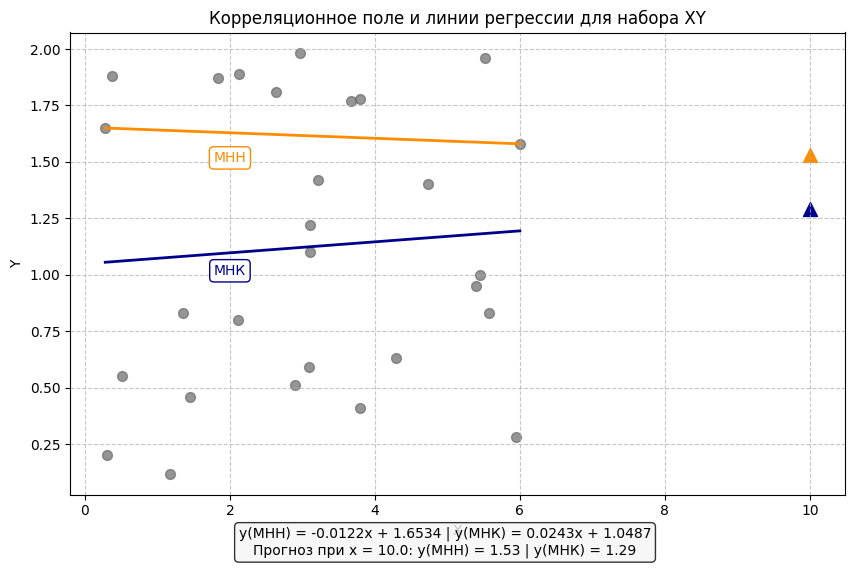

In [39]:
df = pd.DataFrame({'x': x, 'y': y})

x_line = np.linspace(min(x), max(x), 100)
lines = pd.DataFrame({
    'x': x_line,
    'y_mnn': a_mnn * x_line + b_mnn,
    'y_mnk': a_mnk * x_line + b_mnk
})

p_mnn = pd.DataFrame({'x': [x_p], 'y': [y_p_mnn]})
p_mnk = pd.DataFrame({'x': [x_p],  'y': [y_p_mnk]})

plt.figure(figsize=(10, 6))
plt.plot(lines['x'], lines['y_mnn'], color='darkorange', linewidth=2)
plt.annotate('МНН', xy=(2.0, 1.5), color='darkorange', ha='center',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='darkorange'))
plt.plot(lines['x'], lines['y_mnk'], color='darkblue', linewidth=2)
plt.annotate('МНК', xy=(2.0, 1.0), color='darkblue', ha='center',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='darkblue'))
plt.scatter(df['x'], df['y'], color='dimgray', alpha=0.7, s=50)
plt.scatter(p_mnn['x'], p_mnn['y'], marker='^', color='darkorange', s=100)
plt.scatter(p_mnk['x'], p_mnk['y'], marker='^', color='darkblue', s=100)
plt.title('Корреляционное поле и линии регрессии для набора XY')
plt.xlabel('X')
plt.ylabel('Y')
subtitle_text = (f'y(МНН) = {a_mnn:.4f}x + {b_mnn:.4f} | '
                 f'y(МНК) = {a_mnk:.4f}x + {b_mnk:.4f}\n'
                 f'Прогноз при x = {x_p[0] if isinstance(x_p, (list, np.ndarray)) else x_p}: '
                 f'y(МНН) = {y_p_mnn[0] if isinstance(y_p_mnn, (list, np.ndarray)) else y_p_mnn:.2f} | '
                 f'y(МНК) = {y_p_mnk[0] if isinstance(y_p_mnk, (list, np.ndarray)) else y_p_mnk:.2f}')
plt.figtext(0.5, 0.01, subtitle_text, ha='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='whitesmoke', alpha=0.8))
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Проверка гипотезы о значимости коэффициента корреляции

Коэффициент корреляции r_xy = 0.0714
Уровень значимости: 0.05
T_набл = 0.3648
t_крит = +/- 2.0555
|T_набл| < t_крит => H0 не отвергается
Вывод: коэффициент корреляции не значим


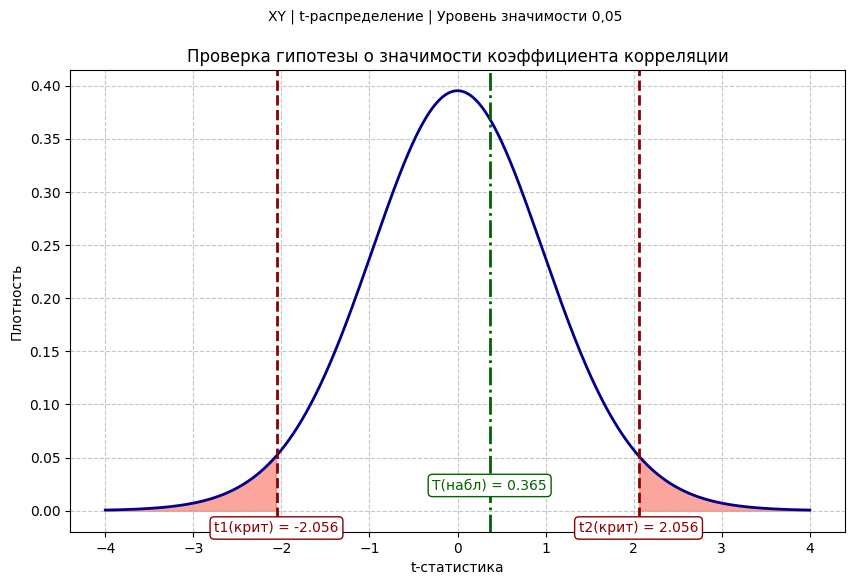

In [40]:
alpha = 0.05
t_nabl = r_xy * np.sqrt(n - 2) / np.sqrt(1 - r_xy**2)
t_crit = stats.t.ppf(1 - alpha/2, n - 2)

print(f"Коэффициент корреляции r_xy = {round(r_xy, 4)}")

print(f"Уровень значимости: {alpha}")

print(f"T_набл = {round(t_nabl, 4)}")
print(f"t_крит = +/- {round(t_crit, 4)}")

if abs(t_nabl) > t_crit:
    print("|T_набл| > t_крит => H0 отвергается")
    print("Вывод: коэффициент корреляции значим")
else:
    print("|T_набл| < t_крит => H0 не отвергается")
    print("Вывод: коэффициент корреляции не значим")

df = n - 2 
x_t = np.linspace(-4, 4, 1000)
y_t = t.pdf(x_t, df=df)
df_t = pd.DataFrame({'x': x_t, 'y': y_t})

df_t_fill_1 = df_t[df_t['x'] <= -t_crit]
df_t_fill_2 = df_t[df_t['x'] >= t_crit]

plt.figure(figsize=(10, 6))
plt.fill_between(df_t_fill_1['x'], df_t_fill_1['y'], color='salmon', alpha=0.7)
plt.fill_between(df_t_fill_2['x'], df_t_fill_2['y'], color='salmon', alpha=0.7)
plt.plot(df_t['x'], df_t['y'], color='darkblue', linewidth=2)
plt.axvline(x=-t_crit, color='darkred', linestyle='--', linewidth=2)
plt.axvline(x=t_crit, color='darkred', linestyle='--', linewidth=2)
plt.axvline(x=t_nabl, color='darkgreen', linestyle='-.', linewidth=2)
plt.annotate(f't1(крит) = {round(-t_crit, 3)}', xy=(-t_crit, -0.02), ha='center',
             color='darkred', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='darkred'))
plt.annotate(f't2(крит) = {round(t_crit, 3)}', xy=(t_crit, -0.02), ha='center',
             color='darkred', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='darkred'))
plt.annotate(f'T(набл) = {round(t_nabl, 3)}', xy=(t_nabl, 0.02), ha='center', color='darkgreen',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='darkgreen'))
plt.title('Проверка гипотезы о значимости коэффициента корреляции')
plt.suptitle('XY | t-распределение | Уровень значимости 0,05', y=0.98, fontsize=10)
plt.xlabel('t-статистика')
plt.ylabel('Плотность')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Набор XZ
### Построение линии регрессии с помощью метода натянутой нити

In [41]:
n = len(x)

# Индексы min и max по X
index_min = np.argmin(x)
index_max = np.argmax(x)

# Крайние точки
x1 = x[index_min]
y1 = z[index_min]
x2 = x[index_max]
y2 = z[index_max]

# Коэффициенты
a_mnn = (y2 - y1) / (x2 - x1)
b_mnn = y1 - a_mnn * x1

# Итоговая формула МНН
y_mnn = a_mnn * x + b_mnn

### Построение линии регрессии с помощью методу наименьших квадратов

In [42]:
slope, intercept, r_value, p_value, std_err = stats.linregress(x, z)

# Коэффициенты
a_mnk = slope
b_mnk = intercept

# Итоговая формула МНК
y_mnk = a_mnk * x + b_mnk

### Прогноз на 4 единицы вперёд

In [43]:
x_max = np.max(x)
x_p = x_max + 4

y_p_mnn = a_mnn * x_p + b_mnn
y_p_mnk = a_mnk * x_p + b_mnk

### Корреляционное поле и линии регрессии

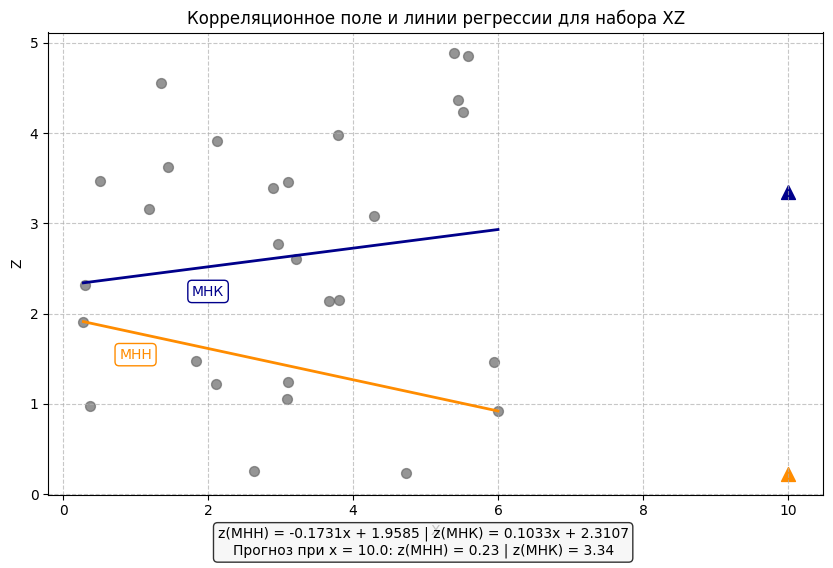

In [44]:
df = pd.DataFrame({'x': x, 'y': z})

x_line = np.linspace(min(x), max(x), 100)
lines = pd.DataFrame({
    'x': x_line,
    'y_mnn': a_mnn * x_line + b_mnn,
    'y_mnk': a_mnk * x_line + b_mnk
})

p_mnn = pd.DataFrame({'x': [x_p], 'y': [y_p_mnn]})
p_mnk = pd.DataFrame({'x': [x_p],  'y': [y_p_mnk]})

plt.figure(figsize=(10, 6))
plt.plot(lines['x'], lines['y_mnn'], color='darkorange', linewidth=2)
plt.annotate('МНН', xy=(1.0, 1.5), color='darkorange', ha='center',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='darkorange'))
plt.plot(lines['x'], lines['y_mnk'], color='darkblue', linewidth=2)
plt.annotate('МНК', xy=(2.0, 2.2), color='darkblue', ha='center',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='darkblue'))
plt.scatter(df['x'], df['y'], color='dimgray', alpha=0.7, s=50)
plt.scatter(p_mnn['x'], p_mnn['y'], marker='^', color='darkorange', s=100)
plt.scatter(p_mnk['x'], p_mnk['y'], marker='^', color='darkblue', s=100)
plt.title('Корреляционное поле и линии регрессии для набора XZ')
plt.xlabel('X')
plt.ylabel('Z')
subtitle_text = (f'z(МНН) = {a_mnn:.4f}x + {b_mnn:.4f} | '
                 f'z(МНК) = {a_mnk:.4f}x + {b_mnk:.4f}\n'
                 f'Прогноз при x = {x_p[0] if isinstance(x_p, (list, np.ndarray)) else x_p}: '
                 f'z(МНН) = {y_p_mnn[0] if isinstance(y_p_mnn, (list, np.ndarray)) else y_p_mnn:.2f} | '
                 f'z(МНК) = {y_p_mnk[0] if isinstance(y_p_mnk, (list, np.ndarray)) else y_p_mnk:.2f}')
plt.figtext(0.5, 0.01, subtitle_text, ha='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='whitesmoke', alpha=0.8))
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Проверка гипотезы о значимости коэффициента корреляции

Коэффициент корреляции r_xz = 0.1325
Уровень значимости: 0.05
T_набл = 0.6815
t_крит = +/- 2.0555
|T_набл| < t_крит => H0 не отвергается
Вывод: коэффициент корреляции не значим


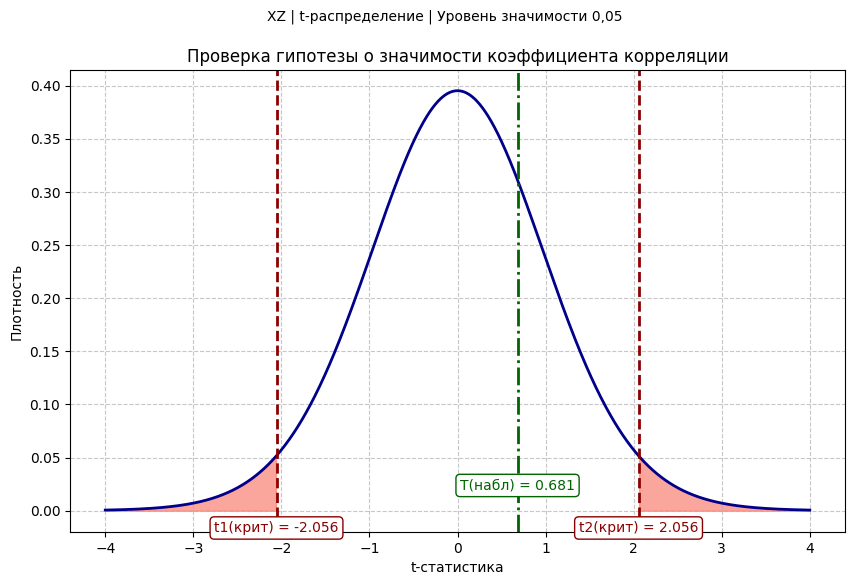

In [45]:
alpha = 0.05
t_nabl = r_xz * np.sqrt(n - 2) / np.sqrt(1 - r_xz**2)
t_crit = stats.t.ppf(1 - alpha/2, n - 2)

print(f"Коэффициент корреляции r_xz = {round(r_xz, 4)}")

print(f"Уровень значимости: {alpha}")

print(f"T_набл = {round(t_nabl, 4)}")
print(f"t_крит = +/- {round(t_crit, 4)}")

if abs(t_nabl) > t_crit:
    print("|T_набл| > t_крит => H0 отвергается")
    print("Вывод: коэффициент корреляции значим")
else:
    print("|T_набл| < t_крит => H0 не отвергается")
    print("Вывод: коэффициент корреляции не значим")

df = n - 2 
x_t = np.linspace(-4, 4, 1000)
y_t = t.pdf(x_t, df=df)
df_t = pd.DataFrame({'x': x_t, 'y': y_t})

df_t_fill_1 = df_t[df_t['x'] <= -t_crit]
df_t_fill_2 = df_t[df_t['x'] >= t_crit]

plt.figure(figsize=(10, 6))
plt.fill_between(df_t_fill_1['x'], df_t_fill_1['y'], color='salmon', alpha=0.7)
plt.fill_between(df_t_fill_2['x'], df_t_fill_2['y'], color='salmon', alpha=0.7)
plt.plot(df_t['x'], df_t['y'], color='darkblue', linewidth=2)
plt.axvline(x=-t_crit, color='darkred', linestyle='--', linewidth=2)
plt.axvline(x=t_crit, color='darkred', linestyle='--', linewidth=2)
plt.axvline(x=t_nabl, color='darkgreen', linestyle='-.', linewidth=2)
plt.annotate(f't1(крит) = {round(-t_crit, 3)}', xy=(-t_crit, -0.02), ha='center',
             color='darkred', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='darkred'))
plt.annotate(f't2(крит) = {round(t_crit, 3)}', xy=(t_crit, -0.02), ha='center',
             color='darkred', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='darkred'))
plt.annotate(f'T(набл) = {round(t_nabl, 3)}', xy=(t_nabl, 0.02), ha='center', color='darkgreen',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='darkgreen'))
plt.title('Проверка гипотезы о значимости коэффициента корреляции')
plt.suptitle('XZ | t-распределение | Уровень значимости 0,05', y=0.98, fontsize=10)
plt.xlabel('t-статистика')
plt.ylabel('Плотность')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Набор YZ
### Построение линии регрессии с помощью метода натянутой нити

In [46]:
n = len(y)

# Индексы min и max по Y
index_min = np.argmin(y)
index_max = np.argmax(y)

# Крайние точки
x1 = y[index_min]
y1 = z[index_min]
x2 = y[index_max]
y2 = z[index_max]

# Коэффициента
a_mnn = (y2 - y1) / (x2 - x1)
b_mnn = y1 - a_mnn * x1

# Итоговая формула МНН
y_mnn = a_mnn * x + b_mnn

### Построение линии регрессии с помощью методу наименьших квадратов

In [47]:
slope, intercept, r_value, p_value, std_err = stats.linregress(y, z)

# Коэффициенты
a_mnk = slope
b_mnk = intercept

# Итоговая формула МНК
y_mnk = a_mnk * x + b_mnk

### Корреляционное поле и линии регрессии

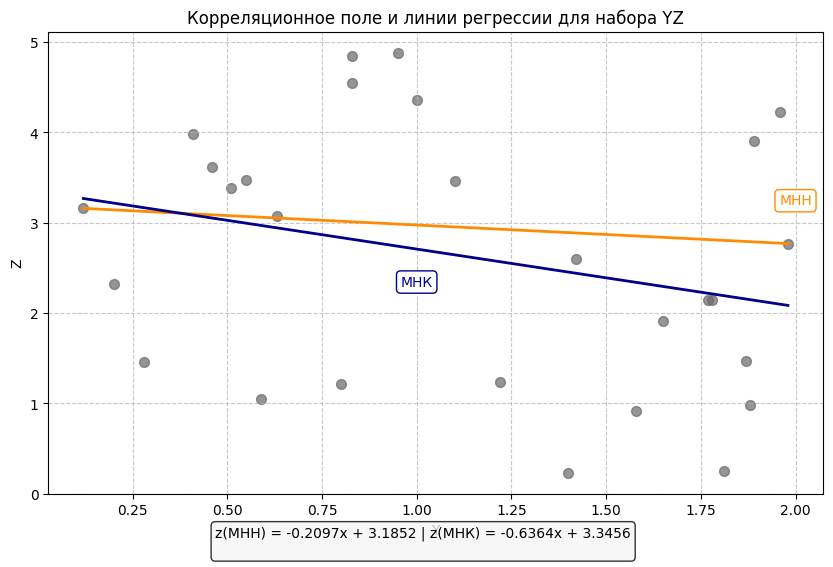

In [48]:
df = pd.DataFrame({'x': y, 'y': z})

x_line = np.linspace(min(y), max(y), 100)
lines = pd.DataFrame({
    'x': x_line,
    'y_mnn': a_mnn * x_line + b_mnn,
    'y_mnk': a_mnk * x_line + b_mnk
})

plt.figure(figsize=(10, 6))
plt.plot(lines['x'], lines['y_mnn'], color='darkorange', linewidth=2)
plt.annotate('МНН', xy=(2.0, 3.2), color='darkorange', ha='center',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='darkorange'))
plt.plot(lines['x'], lines['y_mnk'], color='darkblue', linewidth=2)
plt.annotate('МНК', xy=(1.0, 2.3), color='darkblue', ha='center',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='darkblue'))
plt.scatter(df['x'], df['y'], color='dimgray', alpha=0.7, s=50)
plt.title('Корреляционное поле и линии регрессии для набора YZ')
plt.xlabel('Y')
plt.ylabel('Z')
subtitle_text = (f'z(МНН) = {a_mnn:.4f}x + {b_mnn:.4f} | '
                 f'z(МНК) = {a_mnk:.4f}x + {b_mnk:.4f}\n')
plt.figtext(0.5, 0.01, subtitle_text, ha='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='whitesmoke', alpha=0.8))
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Проверка гипотезы о значимости коэффициента корреляции

Коэффициент корреляции r_yz = -0.2781
Уровень значимости: 0.05
T_набл = -1.4764
t_крит = +/- 2.0555
|T_набл| < t_крит => H0 не отвергается
Вывод: коэффициент корреляции не значим


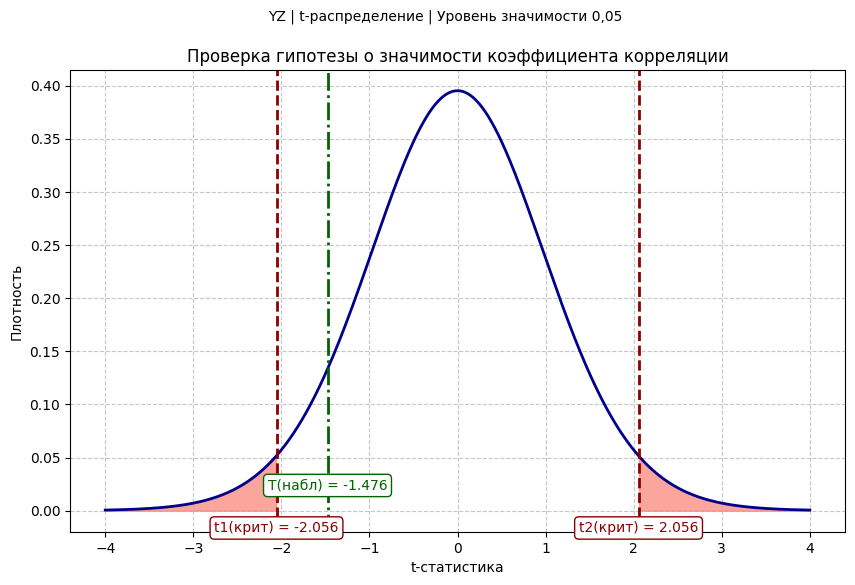

In [49]:
alpha = 0.05
t_nabl = r_yz * np.sqrt(n - 2) / np.sqrt(1 - r_yz**2)
t_crit = stats.t.ppf(1 - alpha/2, n - 2)

print(f"Коэффициент корреляции r_yz = {round(r_yz, 4)}")

print(f"Уровень значимости: {alpha}")

print(f"T_набл = {round(t_nabl, 4)}")
print(f"t_крит = +/- {round(t_crit, 4)}")

if abs(t_nabl) > t_crit:
    print("|T_набл| > t_крит => H0 отвергается")
    print("Вывод: коэффициент корреляции значим")
else:
    print("|T_набл| < t_крит => H0 не отвергается")
    print("Вывод: коэффициент корреляции не значим")

df = n - 2 
x_t = np.linspace(-4, 4, 1000)
y_t = t.pdf(x_t, df=df)
df_t = pd.DataFrame({'x': x_t, 'y': y_t})

df_t_fill_1 = df_t[df_t['x'] <= -t_crit]
df_t_fill_2 = df_t[df_t['x'] >= t_crit]

plt.figure(figsize=(10, 6))
plt.fill_between(df_t_fill_1['x'], df_t_fill_1['y'], color='salmon', alpha=0.7)
plt.fill_between(df_t_fill_2['x'], df_t_fill_2['y'], color='salmon', alpha=0.7)
plt.plot(df_t['x'], df_t['y'], color='darkblue', linewidth=2)
plt.axvline(x=-t_crit, color='darkred', linestyle='--', linewidth=2)
plt.axvline(x=t_crit, color='darkred', linestyle='--', linewidth=2)
plt.axvline(x=t_nabl, color='darkgreen', linestyle='-.', linewidth=2)
plt.annotate(f't1(крит) = {round(-t_crit, 3)}', xy=(-t_crit, -0.02), ha='center',
             color='darkred', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='darkred'))
plt.annotate(f't2(крит) = {round(t_crit, 3)}', xy=(t_crit, -0.02), ha='center',
             color='darkred', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='darkred'))
plt.annotate(f'T(набл) = {round(t_nabl, 3)}', xy=(t_nabl, 0.02), ha='center', color='darkgreen',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='darkgreen'))
plt.title('Проверка гипотезы о значимости коэффициента корреляции')
plt.suptitle('YZ | t-распределение | Уровень значимости 0,05', y=0.98, fontsize=10)
plt.xlabel('t-статистика')
plt.ylabel('Плотность')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()